In [ ]:
# =========================
# FUSION MODEL — FINAL VERSION
# Structured + PCA(NLP radiology) + PCA(CXR BioViL)
# =========================

from google.colab import drive
drive.mount('/content/drive')


Mounted at /content/drive


In [ ]:
import os
import random
import json
import numpy as np
import pandas as pd
from sklearn.model_selection import GroupShuffleSplit
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.decomposition import PCA
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    roc_auc_score, average_precision_score,
    classification_report, confusion_matrix, roc_curve
)
import matplotlib.pyplot as plt
import joblib

print('Imports done ✓')


Imports done ✓


In [ ]:
# -----------------------
# CONFIG
# -----------------------
SEED        = 42
NLP_PCA_DIM = 20
CXR_PCA_DIM = 20

MY_OUT   = '/content/drive/MyDrive/USC/ICU-MM-main/outputs'
KRIS_DIR = '/content/drive/MyDrive/USC/ICU-MM-main/ICU-MM'

MULTIMODAL_CSV   = f'{MY_OUT}/multimodal_df.csv'
CXR_EMBED_CSV    = f'{KRIS_DIR}/biovil_cxr_embeddings_full.csv'

FUSION_DATA_SAVE  = f'{MY_OUT}/fusion_dataset.csv'
MODEL_SAVE        = f'{MY_OUT}/fusion_logreg_pca.pkl'
PCA_SAVE          = f'{MY_OUT}/fusion_pca.pkl'
SCALER_SAVE       = f'{MY_OUT}/fusion_scaler.pkl'
RESULTS_SAVE      = f'{MY_OUT}/fusion_ablation_results.json'

random.seed(SEED)
np.random.seed(SEED)
print('Config set ✓')


Config set ✓


In [ ]:
# -----------------------
# LOAD AND MERGE
# -----------------------
iv_nlp = pd.read_csv(MULTIMODAL_CSV)
cxr    = pd.read_csv(CXR_EMBED_CSV)

# CXR embedding columns from BioViL
cxr_emb_cols  = [c for c in cxr.columns if c.startswith(('emb_', 'cxr_emb_', 'biovil_emb_'))]
cxr = cxr[['subject_id', 'stay_id'] + cxr_emb_cols].copy()

# Merge — BioViL emb_ cols get _cxr suffix if they collide with multimodal emb_ cols
df = iv_nlp.merge(cxr, on=['subject_id', 'stay_id'], how='inner', suffixes=('', '_cxr'))
df = df.drop_duplicates(subset=['stay_id']).reset_index(drop=True)
df['respiratory_failure'] = df['respiratory_failure'].astype(int)

print(f'Merged rows:   {len(df)}')
print(f'Class balance:')
print(df['respiratory_failure'].value_counts(normalize=True).sort_index())

df.to_csv(FUSION_DATA_SAVE, index=False)
print(f'Saved fusion dataset ✓')


Merged rows:   552
Class balance:
respiratory_failure
0    0.603261
1    0.396739
Name: proportion, dtype: float64
Saved fusion dataset ✓


In [ ]:
# -----------------------
# FEATURE BUILDING
# -----------------------
drop_cols = {
    'subject_id', 'stay_id', 'respiratory_failure',
    'rf_time', 'icu_intime', 'icu_outtime', 'feature_cutoff',
    'dcm_path', 'study_id', 'study_datetime',
    'report_text', 'clinical_text',
}

feature_df = df.drop(columns=[c for c in drop_cols if c in df.columns], errors='ignore').copy()

# One-hot encode any remaining categoricals
obj_cols = feature_df.select_dtypes(include=['object', 'category']).columns.tolist()
if obj_cols:
    feature_df = pd.get_dummies(feature_df, columns=obj_cols, drop_first=True)

X_raw  = feature_df.select_dtypes(include=[np.number]).copy()
y      = df['respiratory_failure'].astype(int).values
groups = df['subject_id'].values

# Identify the three modality column groups
cxr_cols        = [c for c in X_raw.columns if c.startswith('emb_') or c.endswith('_cxr')]
nlp_cols        = [c for c in X_raw.columns if c.startswith('rad_emb_')]
structured_cols = [c for c in X_raw.columns
                   if c not in cxr_cols and c not in nlp_cols]

print(f'Feature matrix:  {X_raw.shape}')
print(f'Structured:      {len(structured_cols)}')
print(f'NLP radiology:   {len(nlp_cols)}')
print(f'CXR (BioViL):    {len(cxr_cols)}')


Feature matrix:  (552, 1075)
Structured:      179
NLP radiology:   768
CXR (BioViL):    128


In [ ]:
# -----------------------
# IMPUTE + SPLIT BY SUBJECT
# -----------------------
imputer = SimpleImputer(strategy='median')
X_imp   = imputer.fit_transform(X_raw)

gss1 = GroupShuffleSplit(n_splits=1, test_size=0.20, random_state=SEED)
trainval_idx, test_idx = next(gss1.split(X_imp, y, groups=groups))

X_trainval = X_imp[trainval_idx];  X_test = X_imp[test_idx]
y_trainval = y[trainval_idx];      y_test = y[test_idx]
groups_tv  = groups[trainval_idx]

gss2 = GroupShuffleSplit(n_splits=1, test_size=0.20, random_state=SEED)
train_idx, val_idx = next(gss2.split(X_trainval, y_trainval, groups=groups_tv))

X_train = X_trainval[train_idx];  X_val = X_trainval[val_idx]
y_train = y_trainval[train_idx];  y_val = y_trainval[val_idx]

print(f'Train / Val / Test: {len(X_train)} / {len(X_val)} / {len(X_test)}')
print(f'Train RF rate: {y_train.mean():.1%}')
print(f'Val   RF rate: {y_val.mean():.1%}')
print(f'Test  RF rate: {y_test.mean():.1%}')


Train / Val / Test: 338 / 96 / 118
Train RF rate: 37.3%
Val   RF rate: 41.7%
Test  RF rate: 44.9%


In [ ]:
# -----------------------
# SCALE
# -----------------------
scaler  = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_val   = scaler.transform(X_val)
X_test  = scaler.transform(X_test)

joblib.dump(scaler, SCALER_SAVE)
print('Scaler saved ✓')


Scaler saved ✓


In [ ]:
# -----------------------
# PCA — REDUCE EMBEDDING DIMS
# -----------------------
all_cols = list(X_raw.columns)
nlp_idx  = [all_cols.index(c) for c in nlp_cols]
cxr_idx  = [all_cols.index(c) for c in cxr_cols]
str_idx  = [all_cols.index(c) for c in structured_cols]

pca_nlp = PCA(n_components=NLP_PCA_DIM, random_state=SEED)
pca_cxr = PCA(n_components=CXR_PCA_DIM, random_state=SEED)

# Fit on train only, transform all three splits
nlp_train = pca_nlp.fit_transform(X_train[:, nlp_idx])
nlp_val   = pca_nlp.transform(X_val[:,   nlp_idx])
nlp_test  = pca_nlp.transform(X_test[:,  nlp_idx])

cxr_train = pca_cxr.fit_transform(X_train[:, cxr_idx])
cxr_val   = pca_cxr.transform(X_val[:,   cxr_idx])
cxr_test  = pca_cxr.transform(X_test[:,  cxr_idx])

str_train = X_train[:, str_idx]
str_val   = X_val[:,   str_idx]
str_test  = X_test[:,  str_idx]

# Build fused feature matrices
X_fused_train = np.hstack([str_train, nlp_train, cxr_train])
X_fused_val   = np.hstack([str_val,   nlp_val,   cxr_val])
X_fused_test  = np.hstack([str_test,  nlp_test,  cxr_test])

print(f'NLP variance explained ({NLP_PCA_DIM} dims): {pca_nlp.explained_variance_ratio_.sum():.1%}')
print(f'CXR variance explained ({CXR_PCA_DIM} dims): {pca_cxr.explained_variance_ratio_.sum():.1%}')
print(f'Fused feature matrix:  {X_fused_train.shape}')
print(f'  = {len(structured_cols)} structured + {NLP_PCA_DIM} NLP PCA + {CXR_PCA_DIM} CXR PCA')

joblib.dump({'pca_nlp': pca_nlp, 'pca_cxr': pca_cxr,
             'nlp_cols': nlp_cols, 'cxr_cols': cxr_cols,
             'structured_cols': structured_cols}, PCA_SAVE)
print('PCA objects saved ✓')


NLP variance explained (20 dims): 70.1%
CXR variance explained (20 dims): 98.5%
Fused feature matrix:  (338, 219)
  = 179 structured + 20 NLP PCA + 20 CXR PCA
PCA objects saved ✓


In [ ]:
# -----------------------
# TRAIN FUSION MODEL
# Logistic Regression on PCA-reduced features
# -----------------------
fusion_model = LogisticRegression(
    max_iter=1000,
    class_weight='balanced',
    C=0.1,
    random_state=SEED
)
fusion_model.fit(X_fused_train, y_train)

val_auc = roc_auc_score(y_val, fusion_model.predict_proba(X_fused_val)[:, 1])
print(f'Validation AUROC: {val_auc:.4f}')

joblib.dump(fusion_model, MODEL_SAVE)
print('Fusion model saved ✓')


Validation AUROC: 0.8531
Fusion model saved ✓


Final Test AUROC: 0.8549
Final Test AUPRC: 0.8560

                     precision    recall  f1-score   support

             Stable       0.88      0.71      0.79        65
Respiratory Failure       0.71      0.89      0.79        53

           accuracy                           0.79       118
          macro avg       0.80      0.80      0.79       118
       weighted avg       0.81      0.79      0.79       118

Confusion Matrix:
[[46 19]
 [ 6 47]]


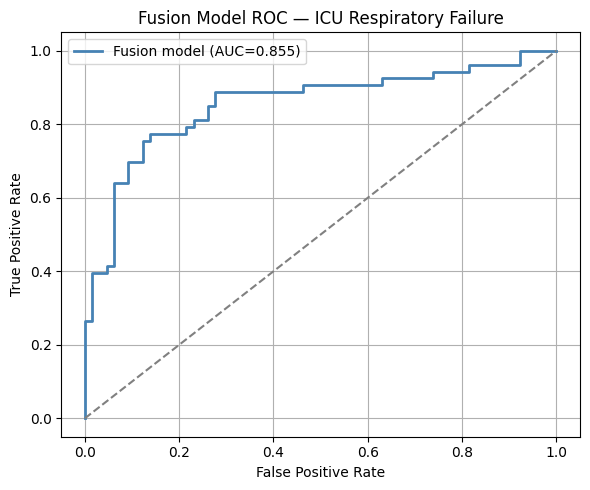

ROC curve saved ✓


In [ ]:
# -----------------------
# FINAL TEST EVALUATION (touch once)
# -----------------------
test_probs = fusion_model.predict_proba(X_fused_test)[:, 1]
test_preds = (test_probs > 0.5).astype(int)

test_auc = roc_auc_score(y_test, test_probs)
test_ap  = average_precision_score(y_test, test_probs)

print(f'Final Test AUROC: {test_auc:.4f}')
print(f'Final Test AUPRC: {test_ap:.4f}')
print()
print(classification_report(y_test, test_preds,
      target_names=['Stable', 'Respiratory Failure']))
print('Confusion Matrix:')
print(confusion_matrix(y_test, test_preds))

# ROC curve
fpr, tpr, _ = roc_curve(y_test, test_probs)
plt.figure(figsize=(6, 5))
plt.plot(fpr, tpr, color='steelblue', linewidth=2,
         label=f'Fusion model (AUC={test_auc:.3f})')
plt.plot([0,1],[0,1],'--',color='gray')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Fusion Model ROC — ICU Respiratory Failure')
plt.legend(); plt.grid(True); plt.tight_layout()
plt.savefig(f'{MY_OUT}/roc_curve_fusion.png', dpi=150)
plt.show()
print('ROC curve saved ✓')


In [ ]:
# -----------------------
# ABLATION — all modality combinations
# -----------------------
experiments = {
    'Structured only':              (str_train,    str_val,    str_test),
    'NLP radiology only':           (nlp_train,    nlp_val,    nlp_test),
    'CXR (BioViL) only':            (cxr_train,    cxr_val,    cxr_test),
    'Structured + NLP':             (np.hstack([str_train, nlp_train]),
                                     np.hstack([str_val,   nlp_val]),
                                     np.hstack([str_test,  nlp_test])),
    'Structured + CXR':             (np.hstack([str_train, cxr_train]),
                                     np.hstack([str_val,   cxr_val]),
                                     np.hstack([str_test,  cxr_test])),
    'NLP + CXR':                    (np.hstack([nlp_train, cxr_train]),
                                     np.hstack([nlp_val,   cxr_val]),
                                     np.hstack([nlp_test,  cxr_test])),
    'All three — fusion (PCA)':     (X_fused_train, X_fused_val, X_fused_test),
}

print(f"{'Experiment':<35} {'Val AUROC':>10} {'Test AUROC':>11}")
print('-' * 58)

ablation_results = {}
for name, (Xtr, Xv, Xte) in experiments.items():
    clf = LogisticRegression(max_iter=1000, class_weight='balanced',
                              C=0.1, random_state=SEED)
    clf.fit(Xtr, y_train)
    v_auc  = roc_auc_score(y_val,  clf.predict_proba(Xv)[:,  1])
    te_auc = roc_auc_score(y_test, clf.predict_proba(Xte)[:, 1])
    ablation_results[name] = {'val_auroc': round(v_auc, 4),
                               'test_auroc': round(te_auc, 4)}
    print(f"{name:<35} {v_auc:>10.4f} {te_auc:>11.4f}")

with open(RESULTS_SAVE, 'w') as f:
    json.dump(ablation_results, f, indent=2)
print(f'\nAblation results saved ✓')


Experiment                           Val AUROC  Test AUROC
----------------------------------------------------------
Structured only                         0.8964      0.8636
NLP radiology only                      0.5728      0.5358
CXR (BioViL) only                       0.5406      0.6380
Structured + NLP                        0.8808      0.8531
Structured + CXR                        0.8884      0.8700
NLP + CXR                               0.5312      0.5684
All three — fusion (PCA)                0.8531      0.8549

Ablation results saved ✓


In [ ]:
# -----------------------
# SAVE FULL RESULTS SUMMARY
# -----------------------
summary = {
    'fusion_model':       'LogisticRegression + PCA',
    'n_samples':          int(len(df)),
    'n_train':            int(len(X_train)),
    'n_val':              int(len(X_val)),
    'n_test':             int(len(X_test)),
    'feature_dims': {
        'structured':     len(structured_cols),
        'nlp_pca':        NLP_PCA_DIM,
        'cxr_pca':        CXR_PCA_DIM,
        'total_fused':    int(X_fused_train.shape[1]),
    },
    'pca_variance_explained': {
        'nlp_20_dims':    round(float(pca_nlp.explained_variance_ratio_.sum()), 4),
        'cxr_20_dims':    round(float(pca_cxr.explained_variance_ratio_.sum()), 4),
    },
    'val_auroc':          round(val_auc,  4),
    'test_auroc':         round(test_auc, 4),
    'test_auprc':         round(test_ap,  4),
    'ablation':           ablation_results,
}

with open(f'{MY_OUT}/fusion_summary.json', 'w') as f:
    json.dump(summary, f, indent=2)

print('Files saved to Drive:')
print(f'  fusion_dataset.csv')
print(f'  fusion_logreg_pca.pkl    — trained fusion model')
print(f'  fusion_pca.pkl           — PCA objects for inference')
print(f'  fusion_scaler.pkl        — StandardScaler for inference')
print(f'  fusion_ablation_results.json')
print(f'  fusion_summary.json')
print(f'  roc_curve_fusion.png')


Files saved to Drive:
  fusion_dataset.csv
  fusion_logreg_pca.pkl    — trained fusion model
  fusion_pca.pkl           — PCA objects for inference
  fusion_scaler.pkl        — StandardScaler for inference
  fusion_ablation_results.json
  fusion_summary.json
  roc_curve_fusion.png
